# Statistiques monitorfish

## Import des packages et des bases

In [2]:
import pandas as pd

In [3]:
message=pd.read_parquet('~/Documents/Stage DAM/Données monitorfish/all_far')
segment=pd.read_csv('~/Documents/Stage DAM/Données monitorfish/segment_flotte.csv')
geo=pd.read_csv('~/Documents/Stage DAM/Données monitorfish/kepler-gl_segments_de_flotte_geographie.csv')

In [4]:
nb_message=len(message)
nb_segment=len(segment)

In [37]:
geo.head()

,0,SEGMENT,POLYGON,OUTIL,OUTILS,ESPECES
0,0,SWW01/02/03,"POLYGON ((-9.272102 43, -9.293329999999999 42....",OTB,"OTB, OTT, PTB, OT, PT, TBN, TBS, TX, TB","HKE, SOL, NEP, ANF"
1,1,SWW01/02/03,"POLYGON ((-9.272102 43, -9.293329999999999 42....",OTT,"OTB, OTT, PTB, OT, PT, TBN, TBS, TX, TB","HKE, SOL, NEP, ANF"
2,2,SWW01/02/03,"POLYGON ((-9.272102 43, -9.293329999999999 42....",PTB,"OTB, OTT, PTB, OT, PT, TBN, TBS, TX, TB","HKE, SOL, NEP, ANF"
3,3,SWW01/02/03,"POLYGON ((-9.272102 43, -9.293329999999999 42....",OT,"OTB, OTT, PTB, OT, PT, TBN, TBS, TX, TB","HKE, SOL, NEP, ANF"
4,4,SWW01/02/03,"POLYGON ((-9.272102 43, -9.293329999999999 42....",PT,"OTB, OTT, PTB, OT, PT, TBN, TBS, TX, TB","HKE, SOL, NEP, ANF"


## Regroupement message -> segment

In [5]:
def isNone(var):
    """Cette fonction vérifie si un object est de classe None ou non"""
    if str(type(var))=="<class 'NoneType'>":
        return True
    else :
        return False
    
def intersection_liste(L1,L2):
    for i in L1 :
        for j in L2:
            if i==j:
                return True
                break
    return False

### Engins

In [6]:
segment_engin={}
for k in range(nb_message):
    segment_engin[k]=[]
    for i in range(nb_segment):
        if intersection_liste([message.value[k]['gear']],segment['Engins'][i].replace(' ','').split(',')):
            segment_engin[k].append(i)
    if k%30000 ==0:
        print('progression',k)

progression 0
progression 30000
progression 60000
progression 90000
progression 120000
progression 150000
progression 180000
progression 210000
progression 240000
progression 270000
progression 300000


### Espèces

Ici nous avons toutes les espèces contenues dans un messages

In [7]:
species={}

for k in range(nb_message): 
    species[k]=[]
    if isNone(message.value[k]['catches'])==True:
        species[k].append(None)
    else :
        for i in range(len(message.value[k]['catches'])):
            species[k].append(message.value[k]['catches'][i]['species'])

Ici nous stockons dans un dictionnaire tous les segments auquelles peuvent appartenir les captures dû a leur espèce.

In [8]:
segment_especes={}
for k in range(nb_message):
    segment_especes[k]=[]
    for s in segment_engin[k]:
        if intersection_liste(species[k],segment['Espèces cibles'][s].replace(' ','').split(',')):
            segment_especes[k].append(s)
    if k%30000 ==0:
        print('progression',k)

progression 0
progression 30000
progression 60000
progression 90000
progression 120000
progression 150000
progression 180000
progression 210000
progression 240000
progression 270000
progression 300000


### Zone FAO

Petite analyse pour voir combien de message renseignent les zones FAO/rectangles, ou sont vides

In [9]:
none=0
fao=0
rect=0
capture_vide=[]
message_vide=[]
for k in range(nb_message): 
    if isNone(message.value[k]['catches'])==True:
        none=none+1
        message_vide.append(k)
    else :
        for i in range(len(message.value[k]['catches'])):
            A=(message.value[k]['catches'][i]['faoZone'])
            B=(message.value[k]['catches'][i]['statisticalRectangle'])
            if isNone(A)==True:
                fao=fao+1
            if isNone(B)==True:
                rect=rect+1
            if (isNone(A)==True) | (isNone(B)==True):
                capture_vide.append(k)
    if k%30000 ==0:
        print('progression',k)

print('\n none',none)
print('fao',fao)
print('rect',rect)

progression 0
progression 30000
progression 60000


KeyboardInterrupt: 

On récupère les zones fao de toutes les messages (une zone FAO par message)

In [10]:
capture_zones={}

for k in range(nb_message): 
    if isNone(message.value[k]['catches'])==True:
        capture_zones[k] = 'None'
    else :
        capture_zones[k] = message.value[k]['catches'][0]['faoZone']
    if k%30000 ==0:
        print('progression',k)

progression 0
progression 30000
progression 60000
progression 90000
progression 120000
progression 150000
progression 180000
progression 210000
progression 240000
progression 270000
progression 300000


Nous stockons dans un dictionnaire les zones FAO de chaque segment

Il faut faire attention a la méditerranée qui n'est pas codée en Zone FAO

In [11]:
segment_zone={}

for i in range(nb_segment):
    segment_zone[i]=[]
    segment_zone_brute=segment['Zones'][i].replace(' ','').split(',')
    for l in range(len(segment_zone_brute)):
        if segment_zone_brute[l]!='Méditerranée':
            segment_FAO = '27.' + segment_zone_brute[l]
            segment_zone[i].append(segment_FAO)
        else :
            segment_zone[i].append(segment_zone_brute[l])

Nous recoupons les espèces et les zones FAO

L'objectif ici est de voir dans quel segment se situe le message. 
Nous prenons les messages potentiels obtenu grace a l'intersection entre les espèces et les captures.
Pour chaque segment potentiel nous regardons quel zone FAO peut éventuellement contenir notre message.
Il faut faire attention car il y a plusieurs niveaux :
Si le message est codé en 27.7.d alors il appartient aux segments 27.7 mais pas aux 27.7.x

In [12]:
segment_message={}
for n in range(nb_message):
    segment_message[n]=[]
    for s in segment_especes[n]:
        if capture_zones[n][:2]=='27' : # Si non méditérannée
            if intersection_liste([capture_zones[n]],segment_zone[s]):
                segment_message[n].append(s)
            if intersection_liste([capture_zones[n][:-2]],segment_zone[s]):
                segment_message[n].append(s)
            if intersection_liste([capture_zones[n][:-4]],segment_zone[s]):
                segment_message[n].append(s)
            if intersection_liste([capture_zones[n][:-6]],segment_zone[s]):
                segment_message[n].append(s)
        elif capture_zones[7][:2]=='37' :
            if intersection_liste(['Méditerranée'],segment_zone[s]):
                segment_message[n].append(s)

# Statistiques descriptives

In [23]:
import matplotlib.pyplot as plt
import numpy as np

### Combien de segment par message

In [14]:
longueur=[]
for i in range(nb_message):
    longueur.append(len(segment_message[i]))

(array([134424.,  44294.,  71935.,  38582.,   9549.,   4445.,    254.]),
 array([0, 1, 2, 3, 4, 5, 6, 7]),
 <BarContainer object of 7 artists>)

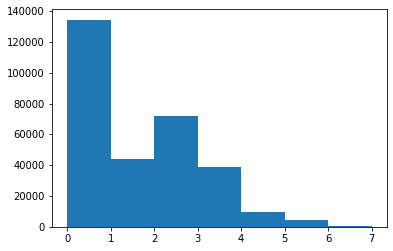

In [15]:
plt.hist(longueur,bins=[0,1,2,3,4,5,6,7])

### Combien de message par segment

In [16]:
list_segment=[]
for i in range(nb_message):
    list_segment.append(segment_message[i])
list_segment = [item for sublist in list_segment for item in sublist]

(array([3.9827e+04, 1.0978e+04, 1.6730e+03, 0.0000e+00, 2.7670e+03,
        2.2502e+04, 2.2650e+04, 2.2650e+04, 1.7230e+03, 0.0000e+00,
        5.1600e+02, 0.0000e+00, 0.0000e+00, 6.5257e+04, 6.5257e+04,
        4.0060e+03, 1.4560e+03, 1.4200e+03, 2.7410e+03, 1.2057e+04,
        2.6030e+03, 6.2340e+03, 0.0000e+00, 4.7320e+03, 4.7330e+03,
        4.5400e+03, 6.0000e+00, 6.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.1000e+01, 1.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.7130e+03, 3.9580e+03, 3.9600e+03, 1.1869e+04,
        7.5500e+02, 7.5500e+02, 4.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 2.0000e+00, 1.0000e+00, 0.0000e+00, 2.7610e+03,
        2.7000e+02, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 4.9040e+03, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00]),
 array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14., 15., 16., 17., 18., 19., 20.

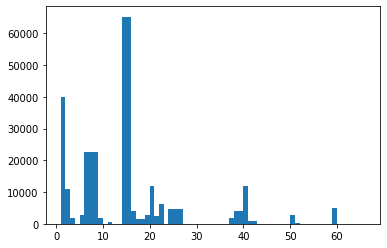

In [33]:
plt.hist(list_segment,bins=np.linspace(1,66,66))